# Fase 1: definición y orientación del problema — Proyecto IrisFlow

## Definición del problema y objetivo

IrisFlow busca determinar si las características morfológicas del dataset Iris
permiten orientar una futura solución de Machine Learning para clasificar flores
en las especies setosa, versicolor y virginica.

El objetivo de este notebook es caracterizar y preparar el conjunto de datos,
verificando su pertinencia para un enfoque de aprendizaje supervisado de
clasificación multiclase.

### Objetivos específicos

- Caracterizar la estructura y las variables del dataset Iris.
- Verificar la calidad y el balance de los datos.
- Explorar las distribuciones y relaciones entre las variables.
- Preparar los predictores para las fases posteriores.
- Justificar el enfoque supervisado de clasificación multiclase.

## Enfoque seleccionado

Se selecciona aprendizaje supervisado porque cada observación dispone de una
etiqueta conocida, Species. Como esta variable es categórica nominal y contiene
tres clases, el problema corresponde a una clasificación multiclase.

En esta Fase 1 no se entrenan ni evalúan modelos.

## Flujo de trabajo

1. Carga y selección del dataset Iris.
2. Inspección de estructura, tipos y calidad de los datos.
3. Análisis estadístico descriptivo y visualización.
4. Análisis exploratorio de relaciones entre variables.
5. Transformación y normalización de los predictores.
6. Preparación de la base para las siguientes fases.

## Librerías necesarias

Importamos las librerías que usaremos para el análisis.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

## Cargar base de datos Iris

Cargamos el conjunto de datos Iris desde `sklearn.datasets` y lo convertimos a un DataFrame de pandas.

In [2]:
iris = load_iris()

bbdd1 = pd.DataFrame(
    iris.data,
    columns=[
        "Sepal.Length",
        "Sepal.Width",
        "Petal.Length",
        "Petal.Width"
    ]
)

# Agregar variable de decisión Species como categórica
bbdd1["Species"] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)

In [3]:
print("Dimensiones del dataset:", bbdd1.shape)

print("\nValores faltantes por variable:")
print(bbdd1.isna().sum())

print("\nDistribución de clases:")
print(bbdd1["Species"].value_counts())

Dimensiones del dataset: (150, 5)

Valores faltantes por variable:
Sepal.Length    0
Sepal.Width     0
Petal.Length    0
Petal.Width     0
Species         0
dtype: int64

Distribución de clases:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Análisis descriptivo inicial

Realizamos un análisis descriptivo de las variables de entrada y la variable de decisión `Species`.

In [4]:
print("Resumen estadístico:")
print(bbdd1.describe(include="all"))

print("\nEstructura de la base de datos:")
print(bbdd1.info())

Resumen estadístico:
        Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
count     150.000000   150.000000    150.000000   150.000000     150
unique           NaN          NaN           NaN          NaN       3
top              NaN          NaN           NaN          NaN  setosa
freq             NaN          NaN           NaN          NaN      50
mean        5.843333     3.057333      3.758000     1.199333     NaN
std         0.828066     0.435866      1.765298     0.762238     NaN
min         4.300000     2.000000      1.000000     0.100000     NaN
25%         5.100000     2.800000      1.600000     0.300000     NaN
50%         5.800000     3.000000      4.350000     1.300000     NaN
75%         6.400000     3.300000      5.100000     1.800000     NaN
max         7.900000     4.400000      6.900000     2.500000     NaN

Estructura de la base de datos:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Nu

In [5]:
print("Resumen estadístico:")
print(bbdd1.describe())

print("\nEstructura de la base de datos:")
print(bbdd1.info())

Resumen estadístico:
       Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Estructura de la base de datos:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Sepal.Length  150 non-null    float64 
 1   Sepal.Width   150 non-null    float64 
 2   Petal.Length  150 non-null    float64 
 3   Petal.Width   150 non-null    float64 
 4   Species       150 non-null    category
dtype

## Visualización de la distribución con Boxplot

Un boxplot nos ayuda a visualizar la distribución de las variables numéricas y a identificar posibles *outliers*.

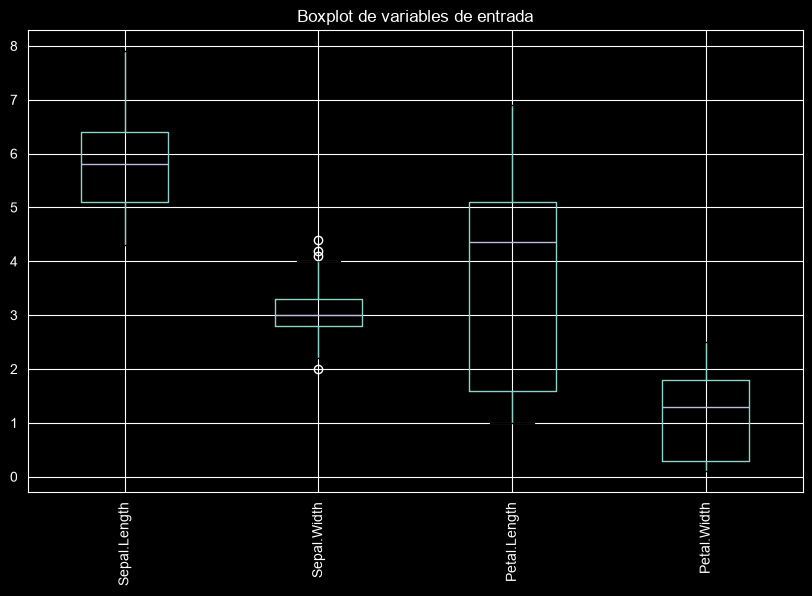

In [6]:
plt.figure(figsize=(10, 6))
bbdd1.iloc[:, 0:4].boxplot()
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("")
plt.title("Boxplot de variables de entrada")
plt.show()

## Transformación de la variable `Species`

Convertimos la variable categórica `Species` a un formato numérico para poder calcular correlaciones.

In [7]:
bbdd2 = bbdd1.copy()

bbdd2["Species"] = bbdd2["Species"].cat.codes + 1
# Se suma +1 para imitar el comportamiento de R,
# donde las categorías se codifican como 1, 2 y 3.
# En Python normalmente serían 0, 1 y 2.

## Revisión y resumen de `bbdd2`

Verificamos la estructura y el resumen estadístico de la nueva base de datos con `Species` numérica.

In [8]:
print("\nEstructura de bbdd2:")
print(bbdd2.info())

print("\nResumen estadístico de bbdd2:")
print(bbdd2.describe())


Estructura de bbdd2:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    int8   
dtypes: float64(4), int8(1)
memory usage: 5.0 KB
None

Resumen estadístico de bbdd2:
       Sepal.Length  Sepal.Width  Petal.Length  Petal.Width     Species
count    150.000000   150.000000    150.000000   150.000000  150.000000
mean       5.843333     3.057333      3.758000     1.199333    2.000000
std        0.828066     0.435866      1.765298     0.762238    0.819232
min        4.300000     2.000000      1.000000     0.100000    1.000000
25%        5.100000     2.800000      1.600000     0.300000    1.000000
50%        5.800000     3.000000      4.350000     1.300000    2.00

## Matriz de correlación

Calculamos y visualizamos la matriz de correlación de Pearson para entender la relación entre las variables.

In [9]:
correlacion = bbdd2.corr(method="pearson")

print("\nMatriz de correlación:")
print(correlacion)


Matriz de correlación:
              Sepal.Length  Sepal.Width  Petal.Length  Petal.Width   Species
Sepal.Length      1.000000    -0.117570      0.871754     0.817941  0.782561
Sepal.Width      -0.117570     1.000000     -0.428440    -0.366126 -0.426658
Petal.Length      0.871754    -0.428440      1.000000     0.962865  0.949035
Petal.Width       0.817941    -0.366126      0.962865     1.000000  0.956547
Species           0.782561    -0.426658      0.949035     0.956547  1.000000


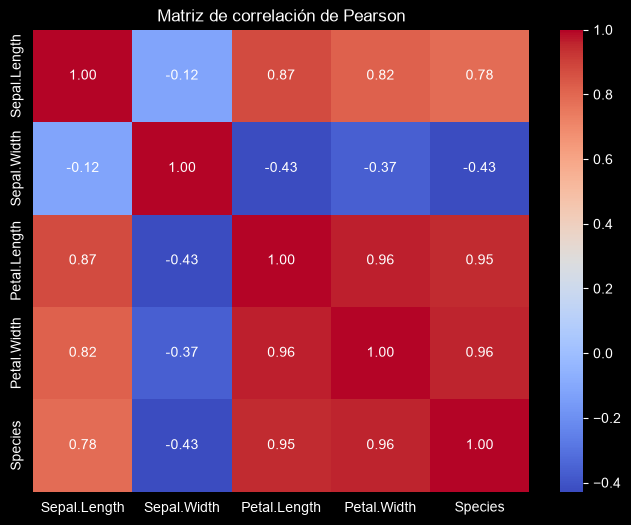

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación de Pearson")
plt.show()

## Normalización de datos

Normalizamos las variables numéricas para escalar sus valores entre 0 y 1, lo cual es útil para ciertos modelos de machine learning.

In [11]:
# Seleccionar variables de entrada
bbdd = bbdd2.iloc[:, 0:4]

In [12]:
scaler = MinMaxScaler()

bbdd_norm = pd.DataFrame(
    scaler.fit_transform(bbdd),
    columns=bbdd.columns
)

## Reintegración de la variable `Species` original

Separamos la variable `Species` original y la unimos con las variables normalizadas.

In [13]:
Species = bbdd1[["Species"]]

In [14]:
bbdd_norm_completa = pd.concat(
    [bbdd_norm, Species],
    axis=1
)

## Base de datos normalizada completa

Mostramos las primeras filas y el resumen estadístico de la base de datos con todas las variables normalizadas y `Species` original.

In [15]:
print("\nBase de datos normalizada completa:")
print(bbdd_norm_completa.head())

print("\nResumen estadístico de base normalizada:")
print(bbdd_norm_completa.describe())


Base de datos normalizada completa:
   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
0      0.222222     0.625000      0.067797     0.041667  setosa
1      0.166667     0.416667      0.067797     0.041667  setosa
2      0.111111     0.500000      0.050847     0.041667  setosa
3      0.083333     0.458333      0.084746     0.041667  setosa
4      0.194444     0.666667      0.067797     0.041667  setosa

Resumen estadístico de base normalizada:
       Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
count    150.000000   150.000000    150.000000   150.000000
mean       0.428704     0.440556      0.467458     0.458056
std        0.230018     0.181611      0.299203     0.317599
min        0.000000     0.000000      0.000000     0.000000
25%        0.222222     0.333333      0.101695     0.083333
50%        0.416667     0.416667      0.567797     0.500000
75%        0.583333     0.541667      0.694915     0.708333
max        1.000000     1.000000      1.000000     1.0000

## Matriz de p-valores para la correlación de Pearson

Podemos calcular los p-valores asociados a cada coeficiente de correlación de Pearson. Un p-valor bajo (típicamente < 0.05) sugiere que la correlación es estadísticamente significativa.

In [16]:
from scipy.stats import pearsonr

def calculate_pvalues(df):
    df = df.dropna()._get_numeric_data() # dropna() to handle missing values and select only numeric columns
    df_cols = df.columns
    pvalues = pd.DataFrame(np.ones(shape=(len(df_cols), len(df_cols))), columns=df_cols, index=df_cols)
    for col1 in df_cols:
        for col2 in df_cols:
            if col1 == col2:
                pvalues.loc[col1, col2] = 0.0 # p-value for correlation with itself is 0
            else:
                _, p = pearsonr(df[col1], df[col2])
                pvalues.loc[col1, col2] = p
    return pvalues

# Calcular la matriz de p-valores para bbdd2
pvalue_matrix = calculate_pvalues(bbdd2)

print("\nMatriz de p-valores (Correlación de Pearson):")
print(pvalue_matrix)


Matriz de p-valores (Correlación de Pearson):
              Sepal.Length   Sepal.Width  Petal.Length   Petal.Width  \
Sepal.Length  0.000000e+00  1.518983e-01  1.038667e-47  2.325498e-37   
Sepal.Width   1.518983e-01  0.000000e+00  4.513314e-08  4.073229e-06   
Petal.Length  1.038667e-47  4.513314e-08  0.000000e+00  4.675004e-86   
Petal.Width   2.325498e-37  4.073229e-06  4.675004e-86  0.000000e+00   
Species       2.890478e-32  5.201563e-08  4.201873e-76  4.155311e-81   

                   Species  
Sepal.Length  2.890478e-32  
Sepal.Width   5.201563e-08  
Petal.Length  4.201873e-76  
Petal.Width   4.155311e-81  
Species       0.000000e+00  


### Visualización de la matriz de p-valores

También podemos visualizar la matriz de p-valores, similar a cómo visualizamos la matriz de correlación, para identificar rápidamente las relaciones significativas.

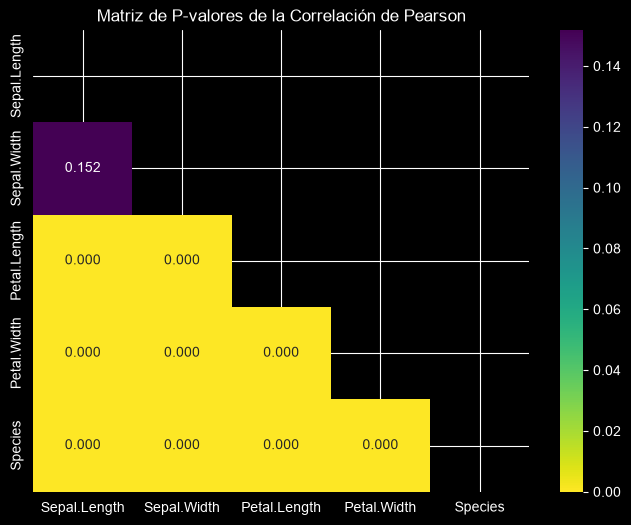

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    pvalue_matrix,
    annot=True,
    cmap="viridis_r", # Using a reversed viridis colormap to highlight low p-values
    fmt=".3f",
    mask=np.triu(np.ones_like(pvalue_matrix, dtype=bool)) # Mask the upper triangle for clarity
)
plt.title("Matriz de P-valores de la Correlación de Pearson")
plt.show()